<a href="https://colab.research.google.com/github/safeera-ea/ecommerce-sales-analytics/blob/main/heart%20disease%20prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PREDICTING HEART DISEASE PROJECT**

Among the 180 patients analyzed, 80 (44%) had heart disease. The strongest individual predictors of heart disease presence were exercise-induced angina, number of major vessels, chest pain type, oldpeak (ST depression), and maximum heart rate achieved — all showing meaningful correlation with the target variable. Sex was also associated, with male patients (sex=1) showing a notably higher heart disease rate (56%) than sex=0 (20%). In contrast, serum cholesterol and fasting blood sugar showed almost no correlation with heart disease and are unlikely to be useful as standalone predictors. These findings suggest a multivariate classification model — such as Logistic Regression,KNN Classification,Decision Tree,Random Forest — trained on the combined feature set (rather than any single variable) would be most effective for accurately predicting heart disease presence.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
labels=pd.read_csv("/content/labels.csv")
values=pd.read_csv("/content/values.csv")

In [ ]:
df=pd.merge(labels,values)

In [ ]:
df.head()

,patient_id,heart_disease_present,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,0,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,0,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,0,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0


In [ ]:
df.describe()

,heart_disease_present,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,0.444444,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667
std,0.498290,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474
min,0.000000,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000
25%,0.000000,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000
50%,0.000000,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000
75%,1.000000,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000
max,1.000000,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000


In [ ]:
df.isnull()

,patient_id,heart_disease_present,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
176,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
177,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
178,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.dropna()

,patient_id,heart_disease_present,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,0,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,0,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,0,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,5qfar3,1,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0
176,2s2b1f,1,2,normal,180,4,0,0,1,327,3.4,0,55,117,1
177,nsd00i,1,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1
178,0xw93k,0,1,normal,124,3,2,1,0,255,0.0,1,48,175,0


In [ ]:
df.isnull().sum()

,0
patient_id,0
heart_disease_present,0
slope_of_peak_exercise_st_segment,0
thal,0
resting_blood_pressure,0
chest_pain_type,0
num_major_vessels,0
fasting_blood_sugar_gt_120_mg_per_dl,0
resting_ekg_results,0
serum_cholesterol_mg_per_dl,0


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
print(df[df.duplicated()])

Empty DataFrame
Columns: [patient_id, heart_disease_present, slope_of_peak_exercise_st_segment, thal, resting_blood_pressure, chest_pain_type, num_major_vessels, fasting_blood_sugar_gt_120_mg_per_dl, resting_ekg_results, serum_cholesterol_mg_per_dl, oldpeak_eq_st_depression, sex, age, max_heart_rate_achieved, exercise_induced_angina]
Index: []


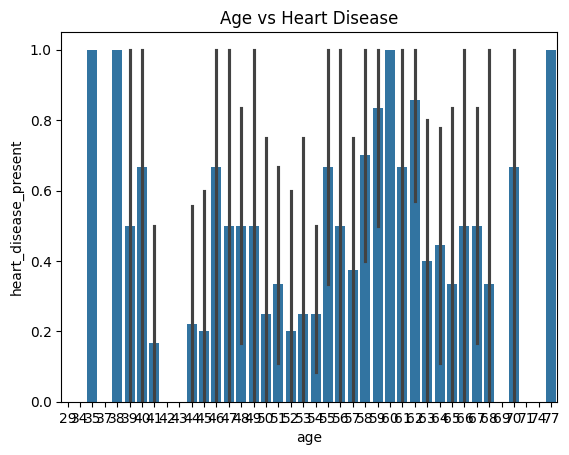

In [ ]:

sns.barplot(x="age",y="heart_disease_present",data=df)
plt.title("Age vs Heart Disease")
plt.show()

***This bar chart visualizes the proportion of heart disease cases at each individual age. While isolated ages with very few patients (mostly below 40 and above 68) show extreme, unreliable proportions (0 or 1) with wide confidence intervals, the more densely sampled 50–65 age range shows a clearer and more trustworthy pattern of increasing heart disease prevalence, generally ranging from 40% to over 80%. This reinforces that heart disease risk rises notably from the mid-50s onward, though age-by-age analysis should be interpreted cautiously due to uneven sample sizes across ages.***

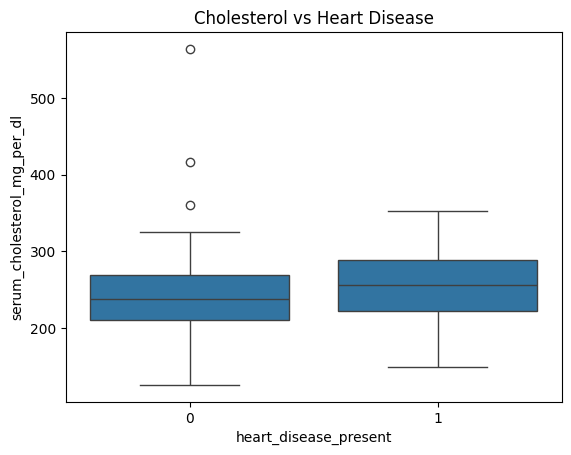

In [ ]:
sns.boxplot(x="heart_disease_present",y="serum_cholesterol_mg_per_dl",data=df)
plt.title("Cholesterol vs Heart Disease")
plt.show()

***There is only a slight difference in serum cholesterol levels between patients with and without heart disease. Patients with heart disease (1) show a marginally higher median cholesterol (255 mg/dl) and greater spread compared to those without (240 mg/dl). However, since the boxes overlap significantly, cholesterol alone does not appear to be a strong standalone differentiator for heart disease in this dataset.***

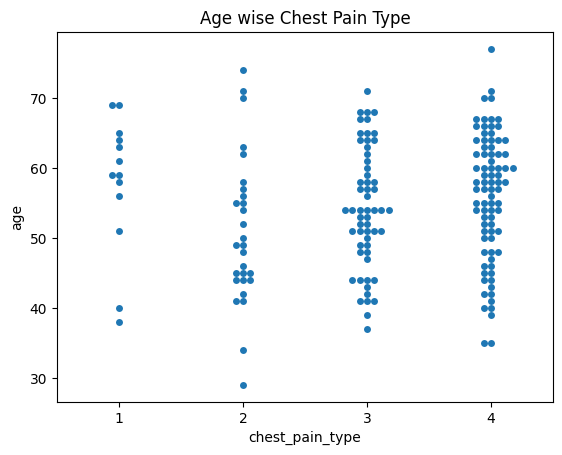

In [ ]:
sns.swarmplot(x="chest_pain_type",y="age",data=df)
plt.title("Age wise Chest Pain Type")
plt.show()

***The swarm plot clearly reveals the distribution and density of patients across the four chest pain types. Chest pain type 3 is the most prevalent among patients, spanning a wide age range with high density, while type 0 is the least common. Across all chest pain categories, the majority of patients fall within the 50–65 age group, indicating this is the most affected age range regardless of chest pain type. This suggests chest pain type distribution is fairly consistent across ages, but its higher prevalence in certain categories (especially type 3) makes it a potentially important feature for heart disease prediction.***

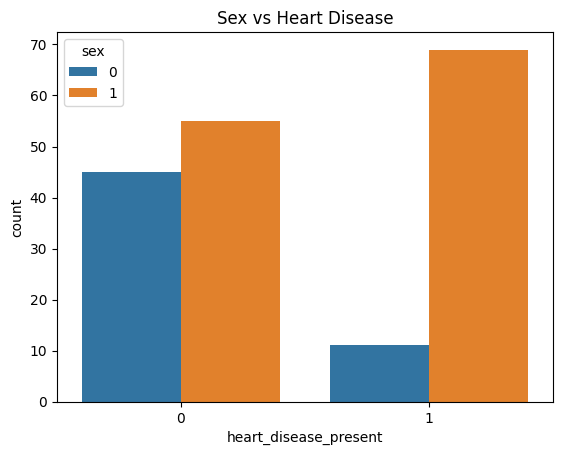

In [ ]:
sns.countplot(x="heart_disease_present",hue="sex",data=df)
plt.title("Sex vs Heart Disease")
plt.show()

***The count plot shows a higher number of heart disease cases among sex group 1 (70) compared to sex group 0. Additionally, within sex group 1, more individuals have heart disease (1) than not (0), suggesting sex may be a relevant factor in heart disease prediction.***

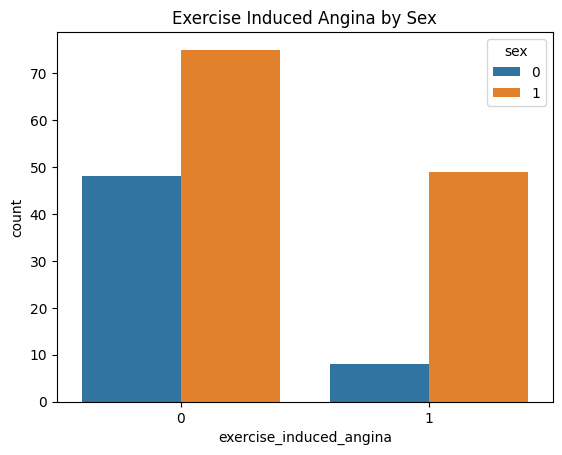

In [ ]:
sns.countplot(x="exercise_induced_angina", hue="sex", data=df)
plt.title("Exercise Induced Angina by Sex")
plt.show()

***This count plot clearly shows that exercise-induced angina is far more common among male patients (sex=1). Among patients without angina, males outnumber females by a moderate margin (75 vs 48), but among patients with angina, this gap widens dramatically — 49 males compared to just 8 females. This confirms that exercise-induced angina occurs disproportionately in male patients within this dataset, making sex an important factor to consider when angina is used as a predictor of heart disease***

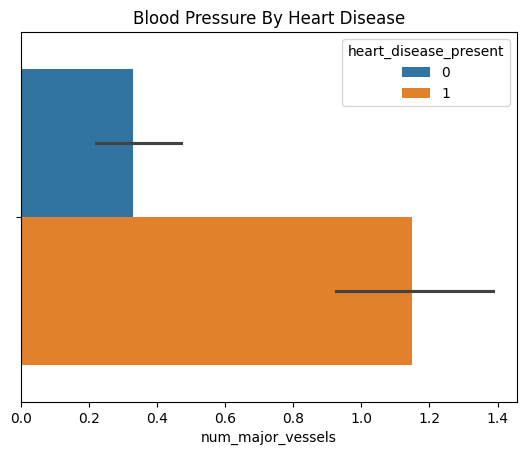

In [ ]:
sns.barplot(x="num_major_vessels", hue="heart_disease_present", data=df)
plt.title("Blood Pressure By Heart Disease")
plt.show()

***This bar chart shows a clear and substantial difference in the average number of major blocked vessels between patients with and without heart disease. Patients without heart disease have an average of only 0.33 blocked vessels, while patients with heart disease have an average of 1.15 — more than three times higher. This strongly confirms that the number of major vessels affected by blockage is one of the most reliable indicators of heart disease presence in this dataset.***

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [ ]:
label=pd.read_csv("/content/labels.csv")
value=pd.read_csv("/content/values.csv")

In [ ]:
df=pd.merge(labels,values)

In [ ]:
x = df.drop(columns=['patient_id','heart_disease_present','thal'])
y = df['heart_disease_present']


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [ ]:
le = LabelEncoder()

In [ ]:
log_reg=LogisticRegression()
log_reg.fit(x_train,y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_pred_log=log_reg.predict(x_test)

In [ ]:
print("Logistic Regression Accuracy:",accuracy_score(y_test,y_pred_log))
print(confusion_matrix(y_test,y_pred_log))
print(classification_report(y_test,y_pred_log))

Logistic Regression Accuracy: 0.8888888888888888
[[20  4]
 [ 0 12]]
              precision    recall  f1-score   support

           0       1.00      0.83      0.91        24
           1       0.75      1.00      0.86        12

    accuracy                           0.89        36
   macro avg       0.88      0.92      0.88        36
weighted avg       0.92      0.89      0.89        36



In [ ]:
knn=KNeighborsClassifier(n_neighbors=40)
knn.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=40)

In [ ]:
y_pred_knn = knn.predict(x_test)

In [ ]:
print("knn Accuracy:",accuracy_score(y_test,y_pred_log))
print(confusion_matrix(y_test,y_pred_knn))
print(classification_report(y_test,y_pred_knn))

knn Accuracy: 0.8888888888888888
[[16  8]
 [ 4  8]]
              precision    recall  f1-score   support

           0       0.80      0.67      0.73        24
           1       0.50      0.67      0.57        12

    accuracy                           0.67        36
   macro avg       0.65      0.67      0.65        36
weighted avg       0.70      0.67      0.68        36



In [ ]:
dt=DecisionTreeClassifier()
dt.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred_dt=dt.predict(x_test)

In [ ]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.75
[[17  7]
 [ 2 10]]
              precision    recall  f1-score   support

           0       0.89      0.71      0.79        24
           1       0.59      0.83      0.69        12

    accuracy                           0.75        36
   macro avg       0.74      0.77      0.74        36
weighted avg       0.79      0.75      0.76        36



In [ ]:
rf=RandomForestClassifier(n_estimators=100,max_depth=6,random_state=0)
rf.fit(x_train, y_train)

RandomForestClassifier(max_depth=6, random_state=0)

In [ ]:
y_pred_rf=rf.predict(x_test)

In [ ]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.75
[[16  8]
 [ 1 11]]
              precision    recall  f1-score   support

           0       0.94      0.67      0.78        24
           1       0.58      0.92      0.71        12

    accuracy                           0.75        36
   macro avg       0.76      0.79      0.75        36
weighted avg       0.82      0.75      0.76        36



In [ ]:
df.head()

,patient_id,heart_disease_present,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,0,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,0,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,0,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0


In [ ]:
import numpy as np
age=int(input("Enter Age:"))
sex=int(input("Enter Sex (0 for female, 1 for male):"))
chest_pain_type=int(input("Enter Chest Pain Type (1-4):"))
resting_blood_pressure=int(input("Enter Resting Blood Pressure:"))
slope_of_peak_exercise_st_segment=int(input("Enter Slope of Peak Exercise ST Segment (1-3):"))
num_major_vessels=int(input("Enter Number of Major Vessels (0-3):"))
fasting_blood_sugar_gt_120_mg_per_dl=int(input("Enter Fasting Blood Sugar ( 1-0):"))
resting_ekg_results=int(input("Enter Resting EKG Results (0-2):"))
max_heart_rate_achieved=int(input("Enter Max Heart Rate Achieved:"))
exercise_induced_angina=int(input("Enter Exercise Induced Angina (1-0):"))
oldpeak_eq_st_depression=float(input("Enter Oldpeak EQ ST Depression value:"))
serum_cholesterol_mg_per_dl=int(input("Enter Serum Cholesterol:"))

input_data=[
    slope_of_peak_exercise_st_segment,
    resting_blood_pressure,
    chest_pain_type,
    num_major_vessels,
    fasting_blood_sugar_gt_120_mg_per_dl,
    resting_ekg_results,
    serum_cholesterol_mg_per_dl,
    oldpeak_eq_st_depression,
    sex,
    age,
    max_heart_rate_achieved,
    exercise_induced_angina
]

input_data_as_numpy_array = np.asarray(input_data)
input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)

prediction=log_reg.predict(input_data_reshaped)

print("\nPrediction:", prediction)
if prediction==1:

  print("The Person Has Heart Disease")
else:
  print("The Person doesn't Have Heart Disease")

Enter Age:45
Enter Sex (0 for female, 1 for male):0
Enter Chest Pain Type (1-4):2
Enter Resting Blood Pressure:128
Enter Slope of Peak Exercise ST Segment (1-3):1
Enter Number of Major Vessels (0-3):0
Enter Fasting Blood Sugar ( 1-0):0
Enter Resting EKG Results (0-2):2
Enter Max Heart Rate Achieved:170
Enter Exercise Induced Angina (1-0):0
Enter Oldpeak EQ ST Depression value:0.0
Enter Serum Cholesterol:308

Prediction: [0]
The Person doesn't Have Heart Disease


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score

comparison=pd.DataFrame({
    "model":["Logistic Regression","KNN","Decision Tree","Random Forest"],
    "accuracy_score":[
        accuracy_score(y_test,y_pred_log),
        accuracy_score(y_test,y_pred_knn),
        accuracy_score(y_test,y_pred_dt),
        accuracy_score(y_test,y_pred_rf)
    ],
    "recall":[
        recall_score(y_test,y_pred_log),
        recall_score(y_test,y_pred_knn),
        recall_score(y_test,y_pred_dt),
        recall_score(y_test,y_pred_rf)
    ]
})
comparison = comparison.sort_values(by=["accuracy_score","recall"],ascending=False)
print(comparison)

                 model  accuracy_score    recall
0  Logistic Regression        0.888889  1.000000
3        Random Forest        0.750000  0.916667
2        Decision Tree        0.750000  0.833333
1                  KNN        0.666667  0.666667


**Project Recommendation**

*  Logistic Regression is the recommended model for this heart disease prediction task — it achieved the highest accuracy (88.9%) and a perfect recall (1.00) on the test set, meaning it correctly identified every actual heart disease case with no false negatives.

*  Recall is the most important metric here, not just accuracy — in a medical diagnosis context, missing a patient who actually has heart disease (false negative) is far more dangerous than a false alarm. Logistic Regression's perfect recall makes it the safest choice for this use case.

*  Random Forest is a strong second option (75% accuracy, 91.7% recall) — it still catches most disease cases and could be considered if more interpretability of feature importance is needed, though it missed 1 positive case in testing.

*   Decision Tree and KNN underperformed relative to the other two models (both at 75% or lower accuracy, with KNN being the weakest at 66.7%). KNN's performance may improve with a better choice of n_neighbors (currently set to 40, which is very high for a dataset of only 180 patients — this likely oversmooths the decision boundary).

*   The dataset is small (only 180 patients, 36 in the test set) — results can vary significantly with different random_state or train-test splits. Before finalizing Logistic Regression as the production model, it is recommended to validate results using k-fold cross-validation rather than a single train-test split.

*   Feature scaling should be verified — Logistic Regression and KNN are sensitive to feature scale, and it should be confirmed that StandardScaler was applied consistently before training these two models (tree-based models like Decision Tree and Random Forest do not require scaling).

*   Hyperparameter tuning is recommended — using to tune KNN's n_neighbors, Decision Tree's max_depth, and Random Forest's n_estimators/max_depth could improve their performance and provide a fairer comparison against Logistic Regression.

*   Collecting more patient data would help — with only 180 records, models (especially KNN) are prone to instability; a larger dataset would give more reliable and generalizable accuracy/recall figures.

*   For deployment, given its balance of high accuracy, perfect recall, and simplicity/interpretability, Logistic Regression is the final recommended model for predicting heart disease presence in this project.




